# All-or-none model simulations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln
from collections import Counter
import networkx as nx

np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

In [2]:
def model(N, p):
    G = nx.Graph()
    G.add_node(0)
    for t in range(1, N):
        u = np.random.randint(0, t)  # pick target uniformly
        G.add_edge(t, u)
        if np.random.random() < p:
            # connect to ALL neighbours of u
            for w in list(G.neighbors(u)):
                if w != t:
                    G.add_edge(t, w)
    return G

In [3]:
def A(N, p):
    return np.exp(gammaln(N + 2*p) - gammaln(1 + 2*p) - gammaln(N))

def B(N, p):
    return np.exp(gammaln(N + 3*p) - gammaln(1 + 3*p) - gammaln(N))

def M_theory(N, p):
    return (N - A(N, p)) / (1 - 2*p)

def T_theory(N, p):
    return 2*p*N / ((1-2*p)*(1-3*p)) + 2*A(N,p)/(1-2*p) - 2*B(N,p)/(1-3*p)

def Pk_theory(k, p):
    logP = (np.log(1-p) - np.log(2+p)
            + gammaln(k + 1 + 1/p) - gammaln(2 + 1/p)
            + gammaln(2 + 2/p) - gammaln(k + 1 + 2/p))
    return np.exp(logP)

## Number of edges vs $p$

N=50 done
N=200 done
N=1000 done


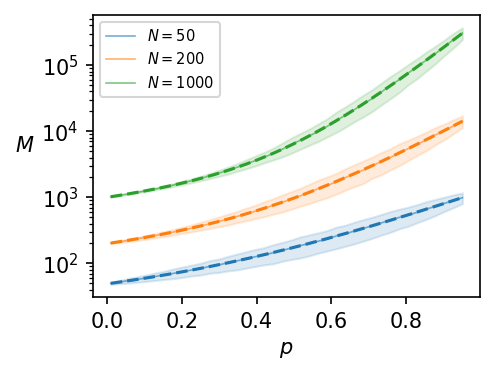

In [ ]:
Ns = [50, 200, 1000]
ps = np.linspace(0.01, 0.95, 40)
trials = 2000
cols = ['C0', 'C1', 'C2']

fig, ax = plt.subplots(figsize=(3.4, 2.6))

all_means = []
for i, N in enumerate(Ns):
    means, stds = [], []
    for p in ps:
        edges = [model(N, p).number_of_edges() for _ in range(trials)]
        means.append(np.mean(edges))
        stds.append(np.std(edges))
    means, stds = np.array(means), np.array(stds)
    all_means.append((means, stds))

    ax.fill_between(ps, means - stds, means + stds, color=cols[i], alpha=0.15)
    ax.plot(ps, means, '-', color=cols[i], lw=0.8, alpha=0.6, label=f'$N={N}$')

pp = np.linspace(0.01, 0.95, 200)
for i, N in enumerate(Ns):
    ax.plot(pp, [M_theory(N, p) for p in pp], '--', color=cols[i], lw=1.5)

ax.set_xlabel('$p$')
ax.set_ylabel('$M$', rotation=0, labelpad=8)
ax.set_yscale('log')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
fig.savefig('figures/edges_vs_p.pdf')
plt.show()

## Degree distribution (sparse regime, $p < 1/2$)

p=0.1 done
p=0.2 done
p=0.3 done


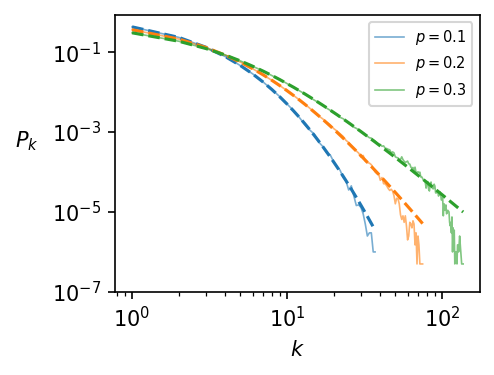

In [ ]:
N = 10000
trials = 200

fig, ax = plt.subplots(figsize=(3.4, 2.6))

all_data = {}
for p in [0.1, 0.2, 0.3]:
    degs = Counter()
    for _ in range(trials):
        G = model(N, p)
        for _, d in G.degree():
            degs[d] += 1
    total = sum(degs.values())
    ks = sorted(degs.keys())
    Psim = [degs[k]/total for k in ks]
    all_data[p] = (ks, Psim)
    ax.plot(ks, Psim, '-', lw=0.8, alpha=0.6, label=f'$p={p}$')

for i, p in enumerate([0.1, 0.2, 0.3]):
    karr = np.arange(1, max(all_data[p][0])+1)
    ax.plot(karr, [Pk_theory(k, p) for k in karr], '--', color=f'C{i}', lw=1.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$k$')
ax.set_ylabel('$P_k$', rotation=0, labelpad=12)
ax.set_ylim(bottom=1e-7)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig('figures/degree_distribution.pdf')
plt.show()

## Triangles

N=50 done
N=200 done
N=500 done


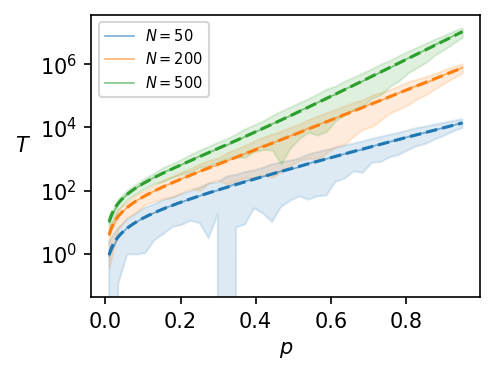

In [ ]:
Ns = [50, 200, 500]
ps = np.linspace(0.01, 0.95, 40)
trials = 1000
cols = ['C0', 'C1', 'C2']

fig, ax = plt.subplots(figsize=(3.4, 2.6))

for i, N in enumerate(Ns):
    means, stds = [], []
    for p in ps:
        tris = []
        for _ in range(trials):
            G = model(N, p)
            tris.append(sum(nx.triangles(G).values()) // 3)
        means.append(np.mean(tris))
        stds.append(np.std(tris))
    means, stds = np.array(means), np.array(stds)

    ax.fill_between(ps, means - stds, means + stds, color=cols[i], alpha=0.15)
    ax.plot(ps, means, '-', color=cols[i], lw=0.8, alpha=0.6, label=f'$N={N}$')

pp = np.concatenate([np.linspace(0.01, 0.32, 100),
                     np.linspace(0.34, 0.49, 50),
                     np.linspace(0.51, 0.95, 100)])
for i, N in enumerate(Ns):
    ax.plot(pp, [T_theory(N, p) for p in pp], '--', color=cols[i], lw=1.5)

ax.set_xlabel('$p$')
ax.set_ylabel('$T$', rotation=0, labelpad=8)
ax.set_yscale('log')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
fig.savefig('figures/triangles_vs_p.pdf')
plt.show()

## Clustering coefficient

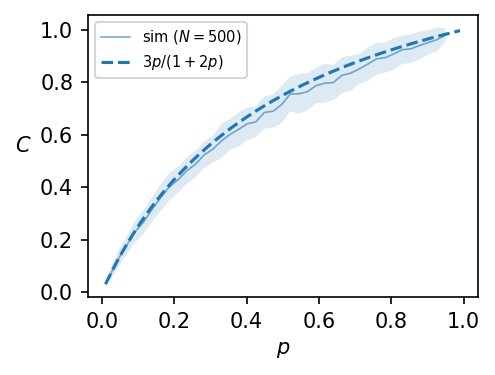

In [48]:
N = 500
ps = np.linspace(0.02, 0.95, 40)
trials = 100

means, stds = [], []
for p in ps:
    vals = [nx.transitivity(model(N, p)) for _ in range(trials)]
    means.append(np.mean(vals))
    stds.append(np.std(vals))
means, stds = np.array(means), np.array(stds)

fig, ax = plt.subplots(figsize=(3.4, 2.6))
ax.fill_between(ps, means - stds, means + stds, alpha=0.15)
ax.plot(ps, means, '-', lw=0.8, alpha=0.6, label=f'sim ($N={N}$)')

pp = np.linspace(0.01, 0.99, 200)
ax.plot(pp, 3*pp/(1+2*pp), '--', color='C0', lw=1.5, label=r'$3p/(1+2p)$')

ax.set_xlabel('$p$')
ax.set_ylabel('$C$', rotation=0, labelpad=8)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig('figures/clustering.pdf')
plt.show()

## Assortativity

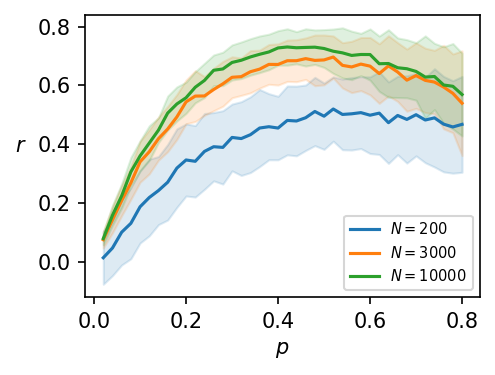

In [ ]:
Ns = [200, 2000, 20000]
ps = np.linspace(0.02, 0.8, 40)
trials = 100
cols = ['C0', 'C1', 'C2']

fig, ax = plt.subplots(figsize=(3.4, 2.6))

for i, N in enumerate(Ns):
    means, stds = [], []
    for p in ps:
        vals = [nx.degree_assortativity_coefficient(model(N, p)) for _ in range(trials)]
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    means, stds = np.array(means), np.array(stds)

    ax.fill_between(ps, means - stds, means + stds, color=cols[i], alpha=0.15)
    ax.plot(ps, means, '-', color=cols[i], lw=1.5, alpha=0.6, label=f'$N={N}$')

pp = np.linspace(0.01, 0.24, 200)
ax.plot(pp, pp*(9-2*pp)/((1+2*pp)*(2-pp)), '--', color='k', lw=1.5, label=r'$p(9-2p)/[(1+2p)(2-p)]$')

ax.set_xlabel('$p$')
ax.set_ylabel('$r$', rotation=0, labelpad=8)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig('figures/assortativity.pdf')
plt.show()

## Average shortest-path distance

p=0.0 done
p=0.1 done
p=0.3 done
p=0.5 done


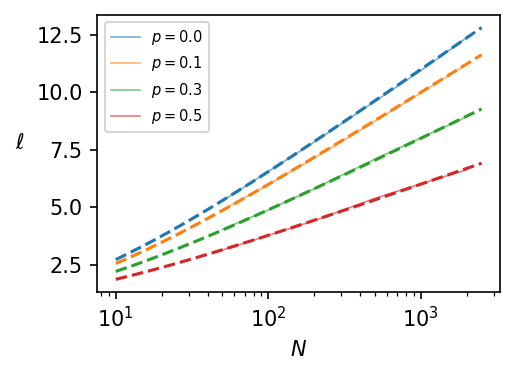

In [ ]:
def ell_theory(N, p):
    # exact finite-N formula from the writeup
    H = np.cumsum(1.0 / np.arange(1, N+2))  # H[k-1] = H_k
    HN = H[N-1]       # H_N
    HN1 = H[N]        # H_{N+1}
    gamma = 2*(2*p - 1)*(HN - 1) + 2*(2 - 3*p)*(HN1 - 1.5)
    return gamma * (N + 1) / (N - 1)

Ns = [50, 100, 200, 500, 1000, 2000]
ps = [0.0, 0.1, 0.3, 0.5]
trials = 200

fig, ax = plt.subplots(figsize=(3.4, 2.6))

all_ells = {}
for i, p in enumerate(ps):
    ells = []
    for N in Ns:
        vals = [nx.average_shortest_path_length(model(N, p)) for _ in range(trials)]
        ells.append(np.mean(vals))
    all_ells[p] = ells
    ax.plot(Ns, ells, '-', color=f'C{i}', lw=0.8, alpha=0.6, label=f'$p={p}$')

Nfine = np.arange(10, 2501)
for i, p in enumerate([0.0, 0.1, 0.3, 0.5]):
    ax.plot(Nfine, [ell_theory(N, p) for N in Nfine], '--', color=f'C{i}', lw=1.5)

ax.set_xscale('log')
ax.set_xlabel('$N$')
ax.set_ylabel(r'$\ell$', rotation=0, labelpad=8)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig('figures/distance.pdf')
plt.show()

In [ ]:
Ns = [50, 100, 200, 500, 1000, 2000]
ps = [0.0, 0.1, 0.5, 0.9, 1]
trials = 200

fig, ax = plt.subplots(figsize=(3.4, 2.6))

for i, p in enumerate(ps):
    means, stds = [], []
    for N in Ns:
        vals = []
        for _ in range(trials):
            G = model(N, p)
            L = nx.laplacian_matrix(G).toarray().astype(float)
            lam2 = np.linalg.eigvalsh(L)[1]
            vals.append(1.0 / lam2)
        means.append(np.mean(vals))
        stds.append(np.std(vals))
    means, stds = np.array(means), np.array(stds)

    ax.fill_between(Ns, means - stds, means + stds, color=f'C{i}', alpha=0.15)
    ax.plot(Ns, means, '-', color=f'C{i}', lw=0.8, alpha=0.6, markersize=3, label=f'$p={p}$')

Nfine = np.linspace(50, 1000, 200)
ax.plot(Nfine, 0.3 * Nfine * np.log(Nfine), '--', color='gray', lw=1.2, label=r'$N \ln N$')
ax.plot(Nfine, 1.0 / Nfine, ':', color='gray', lw=1.2, label=r'$1/N$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$N$')
ax.set_ylabel(r'$\tau$', rotation=0, labelpad=8)
ax.legend(fontsize=6, loc='upper left')
plt.tight_layout()
fig.savefig('figures/spectral_gap.pdf')
plt.show()